In [2]:
# Create a list of numbers from 0 to 9004
numbers = list(range(9004, -1, -1))
url_base = "https://github.com/openjournals/joss-reviews/issues/"

Wordcount >1700: Issue 8998, URL: https://github.com/openjournals/joss-reviews/issues/8998
Wordcount >1700: Issue 8980, URL: https://github.com/openjournals/joss-reviews/issues/8980
Wordcount >1700: Issue 8935, URL: https://github.com/openjournals/joss-reviews/issues/8935
Wordcount >1700: Issue 8926, URL: https://github.com/openjournals/joss-reviews/issues/8926
Wordcount >1700: Issue 8920, URL: https://github.com/openjournals/joss-reviews/issues/8920
Wordcount >1700: Issue 8907, URL: https://github.com/openjournals/joss-reviews/issues/8907
Wordcount >1700: Issue 8905, URL: https://github.com/openjournals/joss-reviews/issues/8905
Wordcount >1700: Issue 8895, URL: https://github.com/openjournals/joss-reviews/issues/8895
Wordcount >1700: Issue 8893, URL: https://github.com/openjournals/joss-reviews/issues/8893
Wordcount >1700: Issue 8868, URL: https://github.com/openjournals/joss-reviews/issues/8868
Wordcount >1700: Issue 8872, URL: https://github.com/openjournals/joss-reviews/issues/8872

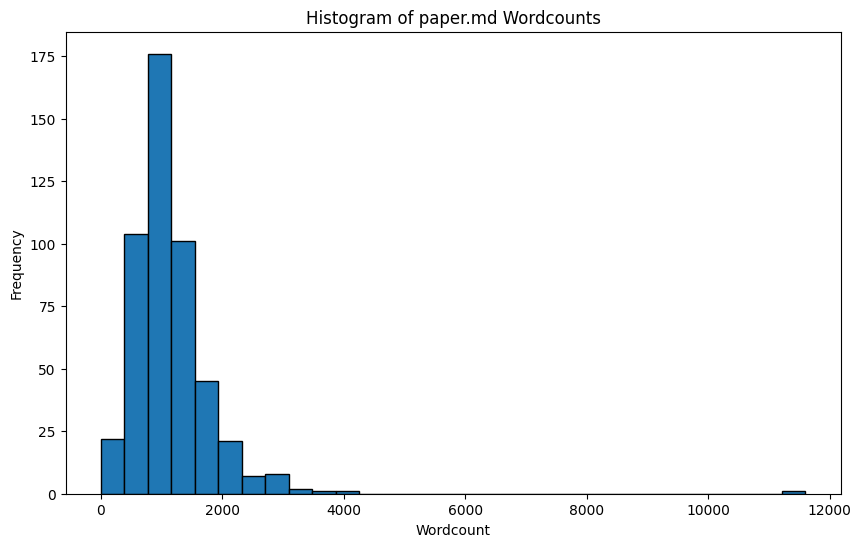

In [3]:
import requests
import re
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

wordcounts = []
wordcount_info = []  # To store (number, url, wordcount) for each found wordcount

def fetch_wordcount(number):
    url = url_base + str(number)
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            match = re.search(r'Wordcount for `paper\.md` is \*\*(\d+)\*\*', response.text)
            if match:
                wordcount = int(match.group(1))
                # Store info for later printing
                return (number, url, wordcount)
        # No print statements except for >1700 as per instructions
    except Exception as e:
        pass
    return None

# Use ThreadPoolExecutor to fetch in parallel
max_workers = 16  # You can adjust this number based on your system/network
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    future_to_number = {executor.submit(fetch_wordcount, number): number for number in numbers}
    for future in as_completed(future_to_number):
        result = future.result()
        if result is not None:
            number, url, wordcount = result
            wordcounts.append(wordcount)
            wordcount_info.append((number, url, wordcount))

# Print number and url for each wordcount > 1700
for number, url, wordcount in wordcount_info:
    if wordcount > 1700:
        print(f"Wordcount >1700: Issue {number}, URL: {url}")

# Print histogram of wordcounts
if wordcounts:
    plt.figure(figsize=(10,6))
    plt.hist(wordcounts, bins=30, edgecolor='black')
    plt.title('Histogram of paper.md Wordcounts')
    plt.xlabel('Wordcount')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("No wordcounts found to plot.")


In [4]:
import numpy as np
np.quantile(wordcounts, [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95])

array([ 409.4,  468.8,  757. , 1060. , 1365. , 1801.4, 2225. ])